In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math
import seaborn as sns

import torch
from torch import nn, Tensor

# Dataset SetUp

In [33]:
data = np.load("DrellYan.npz")
data_H = np.load("Higgs.npz")

taus = data["x_taus"]        # shape (N, 2, 18)
tauprod = data["x_tauprod"]  # shape (N, 10, 10)
met = data["x_met"]          # shape (N, 1, 8)
jets = data["x_jets"]        # shape (N, 3, 4)

target = data["target"]      # (N, 2, 1) gen-level log(pt) of taus
m_reco = data["inv_mass_reco"]  # (N,)
m_target = data["inv_mass_tar"] # (N,)


taus_H   = data_H["x_taus"]          # (N, 2, 18)
tauprod_H = data_H["x_tauprod"]      # (N, 10, 10)
met_H    = data_H["x_met"]           # (N, 1, 8)
jets_H   = data_H["x_jets"]          # (N, 3, 4)

target_H = data_H["target"]          # (N, 2, 1)
m_reco_H  = data_H["inv_mass_reco"]   # (N,)
m_target_H = data_H["inv_mass_tar"]   # (N,)

In [34]:
df = pd.DataFrame({
    "tau1_logpt": taus[:,0,0],
    "tau1_eta":   taus[:,0,1],
    "tau1_phi":   taus[:,0,2],
    "tau1_mass":  taus[:,0,3],
    "tau1_dxy":   taus[:,0,4],
    "tau1_dz":    taus[:,0,5],
    "tau1_ptCorrPNet": taus[:,0,6],
    "tau1_rawPNetVSjet": taus[:,0,7],
    "tau1_rawDeepTau2018v2p5VSjet": taus[:,0,8],
    "tau1_charge": taus[:,0,9],
    
    # decay mode indicator columns 
    "tau1_dM_0":  taus[:,0,10],
    "tau1_dM_1":  taus[:,0,11],
    "tau1_dM_2":  taus[:,0,12],
    "tau1_dM_10": taus[:,0,13],
    "tau1_dM_11": taus[:,0,14],
    
    "tau1_leadTkDeltaEta": taus[:,0,15],
    "tau1_leadTkDeltaPhi": taus[:,0,16],
    "tau1_leadTkPtOverTauPt": taus[:,0,17],

    "tau2_logpt": taus[:,1,0],
    "tau2_eta":   taus[:,1,1],
    "tau2_phi":   taus[:,1,2],
    "tau2_mass":  taus[:,1,3],
    "tau2_dxy":   taus[:,1,4],
    "tau2_dz":    taus[:,1,5],
    "tau2_ptCorrPNet": taus[:,1,6],
    "tau2_rawPNetVSjet": taus[:,1,7],
    "tau2_rawDeepTau2018v2p5VSjet": taus[:,1,8],
    "tau2_charge": taus[:,1,9],

    "tau2_dM_0":  taus[:,1,10],
    "tau2_dM_1":  taus[:,1,11],
    "tau2_dM_2":  taus[:,1,12],
    "tau2_dM_10": taus[:,1,13],
    "tau2_dM_11": taus[:,1,14],

    "tau2_leadTkDeltaEta": taus[:,1,15],
    "tau2_leadTkDeltaPhi": taus[:,1,16],
    "tau2_leadTkPtOverTauPt": taus[:,1,17],

    "gen_tau1_logpt": target[:,0,0],
    "gen_tau2_logpt": target[:,1,0],

    "inv_mass_reco": m_reco,
    "inv_mass_tar":  m_target,
})


df_H = pd.DataFrame({
    "tau1_logpt": taus_H[:,0,0],
    "tau1_eta":   taus_H[:,0,1],
    "tau1_phi":   taus_H[:,0,2],
    "tau1_mass":  taus_H[:,0,3],
    "tau1_dxy":   taus_H[:,0,4],
    "tau1_dz":    taus_H[:,0,5],
    "tau1_ptCorrPNet": taus_H[:,0,6],
    "tau1_rawPNetVSjet": taus_H[:,0,7],
    "tau1_rawDeepTau2018v2p5VSjet": taus_H[:,0,8],
    "tau1_charge": taus_H[:,0,9],
    
    # decay mode indicator columns (same as DY)
    "tau1_dM_0":  taus_H[:,0,10],
    "tau1_dM_1":  taus_H[:,0,11],
    "tau1_dM_2":  taus_H[:,0,12],
    "tau1_dM_10": taus_H[:,0,13],
    "tau1_dM_11": taus_H[:,0,14],
    
    "tau1_leadTkDeltaEta": taus_H[:,0,15],
    "tau1_leadTkDeltaPhi": taus_H[:,0,16],
    "tau1_leadTkPtOverTauPt": taus_H[:,0,17],

    "tau2_logpt": taus_H[:,1,0],
    "tau2_eta":   taus_H[:,1,1],
    "tau2_phi":   taus_H[:,1,2],
    "tau2_mass":  taus_H[:,1,3],
    "tau2_dxy":   taus_H[:,1,4],
    "tau2_dz":    taus_H[:,1,5],
    "tau2_ptCorrPNet": taus_H[:,1,6],
    "tau2_rawPNetVSjet": taus_H[:,1,7],
    "tau2_rawDeepTau2018v2p5VSjet": taus_H[:,1,8],
    "tau2_charge": taus_H[:,1,9],

    "tau2_dM_0":  taus_H[:,1,10],
    "tau2_dM_1":  taus_H[:,1,11],
    "tau2_dM_2":  taus_H[:,1,12],
    "tau2_dM_10": taus_H[:,1,13],
    "tau2_dM_11": taus_H[:,1,14],

    "tau2_leadTkDeltaEta": taus_H[:,1,15],
    "tau2_leadTkDeltaPhi": taus_H[:,1,16],
    "tau2_leadTkPtOverTauPt": taus_H[:,1,17],

    "gen_tau1_logpt": target_H[:,0,0],
    "gen_tau2_logpt": target_H[:,1,0],

    "inv_mass_reco": m_reco_H,
    "inv_mass_tar":  m_target_H,
})


In [35]:
# Per la matrice di correlazione :
jet_features = ['logpt', 'eta', 'phi', 'mass']

met_features = [
    'MET_logpt', 'MET_phi', 'MET_covXX', 'MET_covXY',
    'MET_covYY', 'MET_significance', 'MET_sumEt', 'MET_sumPtUnclustered'
]

df["jet1_logpt"] = jets[:,0,0]
df["jet1_eta"]   = jets[:,0,1]
df["jet1_phi"]   = jets[:,0,2]
df["jet1_mass"]  = jets[:,0,3]

df["jet2_logpt"] = jets[:,1,0]
df["jet2_eta"]   = jets[:,1,1]
df["jet2_phi"]   = jets[:,1,2]
df["jet2_mass"]  = jets[:,1,3]

df["jet3_logpt"] = jets[:,2,0]
df["jet3_eta"]   = jets[:,2,1]
df["jet3_phi"]   = jets[:,2,2]
df["jet3_mass"]  = jets[:,2,3]


met_features = [
    "MET_logpt","MET_phi","MET_covXX","MET_covXY",
    "MET_covYY","MET_significance","MET_sumEt","MET_sumPtUnclustered"
]

for i, name in enumerate(met_features):
    df[name] = met[:,0,i]




df_H["jet1_logpt"] = jets_H[:,0,0]
df_H["jet1_eta"]   = jets_H[:,0,1]
df_H["jet1_phi"]   = jets_H[:,0,2]
df_H["jet1_mass"]  = jets_H[:,0,3]

df_H["jet2_logpt"] = jets_H[:,1,0]
df_H["jet2_eta"]   = jets_H[:,1,1]
df_H["jet2_phi"]   = jets_H[:,1,2]
df_H["jet2_mass"]  = jets_H[:,1,3]

df_H["jet3_logpt"] = jets_H[:,2,0]
df_H["jet3_eta"]   = jets_H[:,2,1]
df_H["jet3_phi"]   = jets_H[:,2,2]
df_H["jet3_mass"]  = jets_H[:,2,3]


for i, name in enumerate(met_features):
    df_H[name] = met_H[:,0,i]

In [36]:
df["tau1_pt_reco"] = np.exp(df["tau1_logpt"])
df["tau2_pt_reco"] = np.exp(df["tau2_logpt"])

df["tau1_pt_gen"] = df["gen_tau1_logpt"]
df["tau2_pt_gen"] = df["gen_tau2_logpt"]


df_H["tau1_pt_reco"] = np.exp(df_H["tau1_logpt"])
df_H["tau2_pt_reco"] = np.exp(df_H["tau2_logpt"])

df_H["tau1_pt_gen"] = df_H["gen_tau1_logpt"]
df_H["tau2_pt_gen"] = df_H["gen_tau2_logpt"]

df["tau1_ptreco_over_ptgen"] = df["tau1_pt_reco"]/df["tau1_pt_gen"]
df["tau2_ptreco_over_ptgen"] = df["tau2_pt_reco"]/df["tau2_pt_gen"]

df_H["tau1_ptreco_over_ptgen"] = df_H["tau1_pt_reco"]/df_H["tau1_pt_gen"]
df_H["tau2_ptreco_over_ptgen"] = df_H["tau2_pt_reco"]/df_H["tau2_pt_gen"]

In [37]:
log_pt_min = np.log(30.0)   # ~3.401

mask_pt = (df["tau1_logpt"] > log_pt_min) & (df["tau2_logpt"] > log_pt_min)

print("Eventi totali:", len(df))
print("Eventi che passano pT>30 GeV (in log):", mask_pt.sum())

df_sel = df[mask_pt].copy()

mask_pt_H = (df_H["tau1_logpt"] > log_pt_min) & (df_H["tau2_logpt"] > log_pt_min)

print("Eventi totali:", len(df_H))
print("Eventi che passano pT>30 GeV (in log):", mask_pt_H.sum())

df_H_sel = df_H[mask_pt_H].copy()

Eventi totali: 335263
Eventi che passano pT>30 GeV (in log): 69198
Eventi totali: 355225
Eventi che passano pT>30 GeV (in log): 158632


In [38]:
df_sel["tau1_abs_eta"] = df_sel["tau1_eta"].abs()
df_sel["tau2_abs_eta"] = df_sel["tau2_eta"].abs()

df_sel["tau1_is_barrel"] = df_sel["tau1_abs_eta"] < 1.4
df_sel["tau1_is_endcap"] = ~df_sel["tau1_is_barrel"]

df_sel["tau2_is_barrel"] = df_sel["tau2_abs_eta"] < 1.4
df_sel["tau2_is_endcap"] = ~df_sel["tau2_is_barrel"]


df_H_sel["tau1_abs_eta"] = df_H_sel["tau1_eta"].abs()
df_H_sel["tau2_abs_eta"] = df_H_sel["tau2_eta"].abs()

df_H_sel["tau1_is_barrel"] = df_H_sel["tau1_abs_eta"] < 1.4
df_H_sel["tau1_is_endcap"] = ~df_H_sel["tau1_is_barrel"]

df_H_sel["tau2_is_barrel"] = df_H_sel["tau2_abs_eta"] < 1.4
df_H_sel["tau2_is_endcap"] = ~df_H_sel["tau2_is_barrel"]

In [39]:
summary = pd.DataFrame({
    "Process": ["Drell–Yan", "Higgs"],
    "Total events": [len(df), len(df_H)],
    "After pT>30 GeV cut": [mask_pt.sum(), mask_pt_H.sum()]
})

summary["Retention (%)"] = 100 * summary["After pT>30 GeV cut"] / summary["Total events"]
summary


,Process,Total events,After pT>30 GeV cut,Retention (%)
0,Drell–Yan,335263,69198,20.639916
1,Higgs,355225,158632,44.656767


In [40]:
# Plot m_reco, m_tar e risoluzione :

# DY (dopo taglio pT)
m_reco_DY    = df_sel["inv_mass_reco"].values
m_target_DY  = df_sel["inv_mass_tar"].values

# Higgs (dopo taglio pT)
m_reco_H     = df_H_sel["inv_mass_reco"].values
m_target_H   = df_H_sel["inv_mass_tar"].values

# Risoluzioni relative
res_DY = (m_reco_DY - m_target_DY) / m_target_DY
res_H  = (m_reco_H  - m_target_H) / m_target_H

In [41]:
df_sel["tau1_response"] = df_sel["tau1_pt_reco"] / df_sel["tau1_pt_gen"]
df_sel["tau1_resolution"] = (df_sel["tau1_pt_reco"] - df_sel["tau1_pt_gen"]) / df_sel["tau1_pt_gen"]

df_sel["tau2_response"] = df_sel["tau2_pt_reco"] / df_sel["tau2_pt_gen"]
df_sel["tau2_resolution"] = (df_sel["tau2_pt_reco"] - df_sel["tau2_pt_gen"]) / df_sel["tau2_pt_gen"]


df_H_sel["tau1_response"] = df_H_sel["tau1_pt_reco"] / df_H_sel["tau1_pt_gen"]
df_H_sel["tau1_resolution"] = (df_H_sel["tau1_pt_reco"] - df_H_sel["tau1_pt_gen"]) / df_H_sel["tau1_pt_gen"]

df_H_sel["tau2_response"] = df_H_sel["tau2_pt_reco"] / df_H_sel["tau2_pt_gen"]
df_H_sel["tau2_resolution"] = (df_H_sel["tau2_pt_reco"] - df_H_sel["tau2_pt_gen"]) / df_H_sel["tau2_pt_gen"]

# pT corretta con PNet
df_sel["tau1_pt_reco_corrPNet"] = df_sel["tau1_pt_reco"] * df_sel["tau1_ptCorrPNet"]
df_sel["tau2_pt_reco_corrPNet"] = df_sel["tau2_pt_reco"] * df_sel["tau2_ptCorrPNet"]

# response corretta
df_sel["tau1_response_corrPNet"] = df_sel["tau1_pt_reco_corrPNet"] / df_sel["tau1_pt_gen"]
df_sel["tau2_response_corrPNet"] = df_sel["tau2_pt_reco_corrPNet"] / df_sel["tau2_pt_gen"]


# pT corretta con PNet
df_H_sel["tau1_pt_reco_corrPNet"] = df_H_sel["tau1_pt_reco"] * df_H_sel["tau1_ptCorrPNet"]
df_H_sel["tau2_pt_reco_corrPNet"] = df_H_sel["tau2_pt_reco"] * df_H_sel["tau2_ptCorrPNet"]

# response corretta
df_H_sel["tau1_response_corrPNet"] = df_H_sel["tau1_pt_reco_corrPNet"] / df_H_sel["tau1_pt_gen"]
df_H_sel["tau2_response_corrPNet"] = df_H_sel["tau2_pt_reco_corrPNet"] / df_H_sel["tau2_pt_gen"]


In [42]:
dm_map = {
    "dM_0": 0, "dM_1": 1, "dM_2": 2,
    "dM_10": 10, "dM_11": 11
}

dm_values = [0, 1, 2, 10, 11]

dm_labels = {
    0: "DM 0 (1-prong, 0 π0)",
    1: "DM 1 (1-prong, 1 π0)",
    2: "DM 2 (1-prong, 2 π0)",
    10: "DM 10 (3-prong, 0 π0)",
    11: "DM 11 (3-prong, 1 π0)",
}


# DY
df_sel["tau1_dm"] = (
      df_sel["tau1_dM_0"]  * 0
    + df_sel["tau1_dM_1"]  * 1
    + df_sel["tau1_dM_2"]  * 2
    + df_sel["tau1_dM_10"] * 10
    + df_sel["tau1_dM_11"] * 11
)

df_sel["tau2_dm"] = (
      df_sel["tau2_dM_0"]  * 0
    + df_sel["tau2_dM_1"]  * 1
    + df_sel["tau2_dM_2"]  * 2
    + df_sel["tau2_dM_10"] * 10
    + df_sel["tau2_dM_11"] * 11
)

# Higgs
df_H_sel["tau1_dm"] = (
      df_H_sel["tau1_dM_0"]  * 0
    + df_H_sel["tau1_dM_1"]  * 1
    + df_H_sel["tau1_dM_2"]  * 2
    + df_H_sel["tau1_dM_10"] * 10
    + df_H_sel["tau1_dM_11"] * 11
)

df_H_sel["tau2_dm"] = (
      df_H_sel["tau2_dM_0"]  * 0
    + df_H_sel["tau2_dM_1"]  * 1
    + df_H_sel["tau2_dM_2"]  * 2
    + df_H_sel["tau2_dM_10"] * 10
    + df_H_sel["tau2_dM_11"] * 11
)

In [43]:
# definizioni utili
# ----- DY -----
df_sel["tau1_response"]   = df_sel["tau1_pt_reco"] / df_sel["tau1_pt_gen"]
df_sel["tau2_response"]   = df_sel["tau2_pt_reco"] / df_sel["tau2_pt_gen"]

df_sel["tau1_resolution"] = df_sel["tau1_response"] - 1.0
df_sel["tau2_resolution"] = df_sel["tau2_response"] - 1.0

# PNet-corrected pT
df_sel["tau1_pt_reco_corrPNet"] = df_sel["tau1_pt_reco"] * df_sel["tau1_ptCorrPNet"]
df_sel["tau2_pt_reco_corrPNet"] = df_sel["tau2_pt_reco"] * df_sel["tau2_ptCorrPNet"]

# PNet-corrected response
df_sel["tau1_response_corrPNet"] = df_sel["tau1_pt_reco_corrPNet"] / df_sel["tau1_pt_gen"]
df_sel["tau2_response_corrPNet"] = df_sel["tau2_pt_reco_corrPNet"] / df_sel["tau2_pt_gen"]

df_sel["tau1_resolution_corrPNet"] = df_sel["tau1_response_corrPNet"] - 1.0
df_sel["tau2_resolution_corrPNet"] = df_sel["tau2_response_corrPNet"] - 1.0


# ----- HIGGS -----
df_H_sel["tau1_response"]   = df_H_sel["tau1_pt_reco"] / df_H_sel["tau1_pt_gen"]
df_H_sel["tau2_response"]   = df_H_sel["tau2_pt_reco"] / df_H_sel["tau2_pt_gen"]

df_H_sel["tau1_resolution"] = df_H_sel["tau1_response"] - 1.0
df_H_sel["tau2_resolution"] = df_H_sel["tau2_response"] - 1.0

# PNet-corrected pT
df_H_sel["tau1_pt_reco_corrPNet"] = df_H_sel["tau1_pt_reco"] * df_H_sel["tau1_ptCorrPNet"]
df_H_sel["tau2_pt_reco_corrPNet"] = df_H_sel["tau2_pt_reco"] * df_H_sel["tau2_ptCorrPNet"]

# PNet-corrected response
df_H_sel["tau1_response_corrPNet"] = df_H_sel["tau1_pt_reco_corrPNet"] / df_H_sel["tau1_pt_gen"]
df_H_sel["tau2_response_corrPNet"] = df_H_sel["tau2_pt_reco_corrPNet"] / df_H_sel["tau2_pt_gen"]

df_H_sel["tau1_resolution_corrPNet"] = df_H_sel["tau1_response_corrPNet"] - 1.0
df_H_sel["tau2_resolution_corrPNet"] = df_H_sel["tau2_response_corrPNet"] - 1.0


# $\tau$ ID

In [44]:
# ================================
# EVENT-LEVEL VALID — Drell–Yan
# (tengo solo eventi con tau1 e tau2 validi)
# ================================

df_sel_valid = df_sel[
    (df_sel["tau1_rawPNetVSjet"] != -1) &
    (df_sel["tau2_rawPNetVSjet"] != -1)
].copy()

print("DY valid events =", len(df_sel_valid))


# ================================
# EVENT-LEVEL VALID — Higgs
# ================================

df_H_sel_valid = df_H_sel[
    (df_H_sel["tau1_rawPNetVSjet"] != -1) &
    (df_H_sel["tau2_rawPNetVSjet"] != -1)
].copy()

print("Higgs valid events =", len(df_H_sel_valid))


DY valid events = 68774
Higgs valid events = 157892


In [45]:
df_sel_tau1_valid = df_sel_valid.copy()
df_sel_tau2_valid = df_sel_valid.copy()

df_H_sel_tau1_valid = df_H_sel_valid.copy()
df_H_sel_tau2_valid = df_H_sel_valid.copy()

print("\nCheck lengths:")
print("DY:", len(df_sel_tau1_valid), len(df_sel_tau2_valid))
print("H :", len(df_H_sel_tau1_valid), len(df_H_sel_tau2_valid))



Check lengths:
DY: 68774 68774
H : 157892 157892


In [46]:
def find_threshold_for_efficiency(thresholds, efficiencies, target_eff=0.90):
    """
    Trova la soglia il cui valore di efficienza è più vicino a target_eff.
    """
    idx = np.argmin(np.abs(efficiencies - target_eff))
    return thresholds[idx], efficiencies[idx]

target_eff = 0.90


# ================================================
# TAU1 — HIGGS (event-level sample)
# ================================================
vals_tau1 = df_H_sel_valid["tau1_rawPNetVSjet"].values

# soglie possibili
thresholds_tau1 = np.sort(np.unique(vals_tau1))

# efficienza: P(rawPNet > thr)
eff_tau1 = np.array([
    np.mean(vals_tau1 > thr) for thr in thresholds_tau1
])

thr_tau1, eff_at_thr_tau1 = find_threshold_for_efficiency(
    thresholds_tau1, eff_tau1, target_eff
)

print(f"[Higgs] Tau1: soglia = {thr_tau1:.6f}, efficienza ≈ {eff_at_thr_tau1:.4f}")


# ================================================
# TAU2 — HIGGS (event-level sample)
# ================================================
vals_tau2 = df_H_sel_valid["tau2_rawPNetVSjet"].values

thresholds_tau2 = np.sort(np.unique(vals_tau2))

eff_tau2 = np.array([
    np.mean(vals_tau2 > thr) for thr in thresholds_tau2
])

thr_tau2, eff_at_thr_tau2 = find_threshold_for_efficiency(
    thresholds_tau2, eff_tau2, target_eff
)

print(f"[Higgs] Tau2: soglia = {thr_tau2:.6f}, efficienza ≈ {eff_at_thr_tau2:.4f}")


[Higgs] Tau1: soglia = 0.642090, efficienza ≈ 0.9000
[Higgs] Tau2: soglia = 0.495850, efficienza ≈ 0.9000


In [47]:
# ============================
# HIGGS: applico le soglie (EVENT-LEVEL)
# ============================

mask_H_tau1 = df_H_sel_valid["tau1_rawPNetVSjet"] > thr_tau1
mask_H_tau2 = df_H_sel_valid["tau2_rawPNetVSjet"] > thr_tau2
mask_H_evt  = mask_H_tau1 & mask_H_tau2

df_H_sel_tauID = df_H_sel_valid[mask_H_evt].copy()

# efficienza event-level (questa è quella “giusta”)
eff_H_evt = mask_H_evt.mean() if len(df_H_sel_valid) > 0 else float("nan")

print("[Higgs] efficienze con soglie (event-level AND):")
print(f"  eventi (tau1 & tau2): {eff_H_evt:.4f}")

# diagnostica: efficienze “oggetto” sullo stesso sample di eventi validi
eff_H_tau1_obj = mask_H_tau1.mean() if len(df_H_sel_valid) > 0 else float("nan")
eff_H_tau2_obj = mask_H_tau2.mean() if len(df_H_sel_valid) > 0 else float("nan")
print("[Higgs] (oggetto, stesso sample):")
print(f"  tau1: {eff_H_tau1_obj:.4f}")
print(f"  tau2: {eff_H_tau2_obj:.4f}")


# ============================
# DY: applico le STESSE soglie (EVENT-LEVEL)
# ============================

mask_DY_tau1 = df_sel_valid["tau1_rawPNetVSjet"] > thr_tau1
mask_DY_tau2 = df_sel_valid["tau2_rawPNetVSjet"] > thr_tau2
mask_DY_evt  = mask_DY_tau1 & mask_DY_tau2

df_sel_tauID = df_sel_valid[mask_DY_evt].copy()

eff_DY_evt = mask_DY_evt.mean() if len(df_sel_valid) > 0 else float("nan")

print("\n[DY] efficienze risultanti con soglie fissate da Higgs (event-level AND):")
print(f"  eventi (tau1 & tau2): {eff_DY_evt:.4f}")

# diagnostica: oggetto
eff_DY_tau1_obj = mask_DY_tau1.mean() if len(df_sel_valid) > 0 else float("nan")
eff_DY_tau2_obj = mask_DY_tau2.mean() if len(df_sel_valid) > 0 else float("nan")
print("[DY] (oggetto, stesso sample):")
print(f"  tau1: {eff_DY_tau1_obj:.4f}")
print(f"  tau2: {eff_DY_tau2_obj:.4f}")



[Higgs] efficienze con soglie (event-level AND):
  eventi (tau1 & tau2): 0.8109
[Higgs] (oggetto, stesso sample):
  tau1: 0.9000
  tau2: 0.9000

[DY] efficienze risultanti con soglie fissate da Higgs (event-level AND):
  eventi (tau1 & tau2): 0.7477
[DY] (oggetto, stesso sample):
  tau1: 0.8526
  tau2: 0.8725


In [48]:
df_tauid_thresholds = pd.DataFrame({
    "Tau": ["Tau1", "Tau2"],
    "Threshold (rawPNet)": [thr_tau1, thr_tau2],
    "Target object efficiency (%)": [90.0, 90.0],
    "Higgs object efficiency (%)": [
        eff_H_tau1_obj * 100,
        eff_H_tau2_obj * 100
    ],
    "DY object efficiency (%)": [
        eff_DY_tau1_obj * 100,
        eff_DY_tau2_obj * 100
    ]
})

df_tauid_thresholds = df_tauid_thresholds.set_index("Tau")
df_tauid_thresholds


,Threshold (rawPNet),Target object efficiency (%),Higgs object efficiency (%),DY object efficiency (%)
Tau,,,,
Tau1,0.64209,90.0,90.003293,85.261872
Tau2,0.49585,90.0,90.004560,87.249542


In [49]:
df_DY_event = df_sel_tauID.copy()
df_H_event = df_H_sel_tauID.copy()

In [50]:
df_DY_event

,tau1_logpt,tau1_eta,tau1_phi,tau1_mass,tau1_dxy,tau1_dz,tau1_ptCorrPNet,tau1_rawPNetVSjet,tau1_rawDeepTau2018v2p5VSjet,tau1_charge,...,tau2_response,tau2_resolution,tau1_pt_reco_corrPNet,tau2_pt_reco_corrPNet,tau1_response_corrPNet,tau2_response_corrPNet,tau1_dm,tau2_dm,tau1_resolution_corrPNet,tau2_resolution_corrPNet
2,3.674162,0.875122,-0.090088,0.646484,-0.000050,0.000212,1.153320,0.914062,0.984863,-1.0,...,0.914873,-0.085127,45.458812,35.007927,0.974988,0.894771,1.0,10.0,-0.025012,-0.105229
6,3.694579,2.389160,1.977051,1.098633,-0.001568,0.005698,1.026367,0.996094,0.994629,1.0,...,0.850390,-0.149610,41.289354,41.035457,0.902500,0.901878,10.0,1.0,-0.097500,-0.098122
9,3.875156,-0.371704,0.386658,1.157227,0.000169,-0.001055,1.019531,0.999023,0.997559,-1.0,...,0.979220,-0.020780,49.131415,30.844352,0.929199,0.981132,10.0,1.0,-0.070801,-0.018868
17,3.964924,0.317871,1.018311,1.087891,-0.001331,-0.000872,0.998535,0.888672,0.994629,1.0,...,0.618578,-0.381422,52.639059,31.170514,0.929608,0.623410,1.0,0.0,-0.070392,-0.376590
25,3.511394,1.427734,0.866943,1.159180,0.000447,0.009053,0.967773,0.906738,0.992188,1.0,...,0.735075,-0.264925,32.415494,34.021892,0.743049,0.788913,1.0,10.0,-0.256951,-0.211087
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
335247,3.621049,0.668579,-1.771973,0.139526,0.001639,-0.000466,1.020508,0.988770,0.995605,-1.0,...,0.822673,-0.177327,38.143286,37.213682,0.833733,0.860432,0.0,0.0,-0.166267,-0.139568
335248,3.866463,0.207764,-0.460815,8.117188,0.030228,0.039980,0.803223,0.996582,-1.000000,-1.0,...,0.657699,-0.342301,38.372454,36.768819,0.730904,0.673113,1.0,0.0,-0.269096,-0.326887
335250,3.591280,0.836426,-0.882080,0.139526,-0.000064,0.000663,1.022461,0.869629,0.966797,-1.0,...,0.730076,-0.269924,37.095369,31.822474,0.893864,0.740058,0.0,10.0,-0.106136,-0.259942
335252,3.735802,-0.003489,-0.321960,7.296875,-0.002762,0.010244,0.840332,0.984863,-1.000000,-1.0,...,0.696674,-0.303326,35.228097,32.708994,0.924016,0.713003,1.0,10.0,-0.075984,-0.286997


In [51]:
df_H_event

,tau1_logpt,tau1_eta,tau1_phi,tau1_mass,tau1_dxy,tau1_dz,tau1_ptCorrPNet,tau1_rawPNetVSjet,tau1_rawDeepTau2018v2p5VSjet,tau1_charge,...,tau2_response,tau2_resolution,tau1_pt_reco_corrPNet,tau2_pt_reco_corrPNet,tau1_response_corrPNet,tau2_response_corrPNet,tau1_dm,tau2_dm,tau1_resolution_corrPNet,tau2_resolution_corrPNet
0,3.750918,0.149750,-2.504883,0.919922,0.001779,0.000654,1.097656,0.985840,0.997559,1.0,...,0.845754,-0.154246,46.716416,44.649644,0.836088,0.989466,1.0,1.0,-0.163912,-0.010534
1,3.908546,-0.357422,-2.585938,0.139526,0.006088,0.012403,0.971680,0.966797,0.997559,1.0,...,0.897412,-0.102588,48.415350,42.992980,0.780893,0.924580,0.0,0.0,-0.219107,-0.075420
6,3.735467,0.549683,1.355957,0.788574,0.002239,0.000944,1.020508,0.999023,0.999512,-1.0,...,0.818558,-0.181442,42.767043,31.457024,0.715766,0.830548,1.0,0.0,-0.284234,-0.169452
10,3.729789,0.430664,-0.860352,0.687012,0.011436,-0.025360,1.043945,0.988281,0.999512,1.0,...,0.531978,-0.468022,43.501531,38.147589,0.805584,0.544966,1.0,1.0,-0.194416,-0.455034
14,4.210932,1.539795,0.115631,8.835938,-0.506348,1.439453,0.895996,0.809082,-1.000000,1.0,...,0.586712,-0.413288,60.407485,38.603266,0.891623,0.630257,1.0,0.0,-0.108377,-0.369743
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
355215,4.048012,-0.148254,-0.296021,0.499023,0.006256,-0.002593,1.053711,0.997070,0.991211,1.0,...,0.647763,-0.352237,60.360228,43.611693,0.981467,0.758464,1.0,1.0,-0.018533,-0.241536
355216,3.832828,-1.078857,-1.057373,1.222656,-0.000417,-0.002056,1.019531,0.999023,0.994629,-1.0,...,0.816822,-0.183178,47.095196,35.609318,0.765776,0.802464,10.0,1.0,-0.234224,-0.197536
355217,4.351929,0.073349,-0.372009,13.562500,-0.004543,3.602661,0.901855,0.769531,-1.000000,-1.0,...,0.563180,-0.436820,70.009306,31.586895,0.952508,0.576930,2.0,1.0,-0.047492,-0.423070
355219,3.875998,0.232666,1.962646,5.148438,0.012688,0.028769,0.967773,0.999023,-1.000000,-1.0,...,0.722039,-0.277961,46.676508,41.002581,0.608163,0.805948,2.0,1.0,-0.391837,-0.194052


In [52]:
# Sistemo i nomi delle colonne sbagliate :
# ========= DY =========
df_DY_event = df_DY_event.copy()

# reco
df_DY_event["tau1_pt_reco"] = np.exp(df_DY_event["tau1_logpt"])
df_DY_event["tau2_pt_reco"] = np.exp(df_DY_event["tau2_logpt"])

# gen 
df_DY_event["tau1_pt_gen"] = df_DY_event["gen_tau1_logpt"]
df_DY_event["tau2_pt_gen"] = df_DY_event["gen_tau2_logpt"]

# ========= Higgs =========
df_H_event = df_H_event.copy()

df_H_event["tau1_pt_reco"] = np.exp(df_H_event["tau1_logpt"])
df_H_event["tau2_pt_reco"] = np.exp(df_H_event["tau2_logpt"])

df_H_event["tau1_pt_gen"] = df_H_event["gen_tau1_logpt"]
df_H_event["tau2_pt_gen"] = df_H_event["gen_tau2_logpt"]


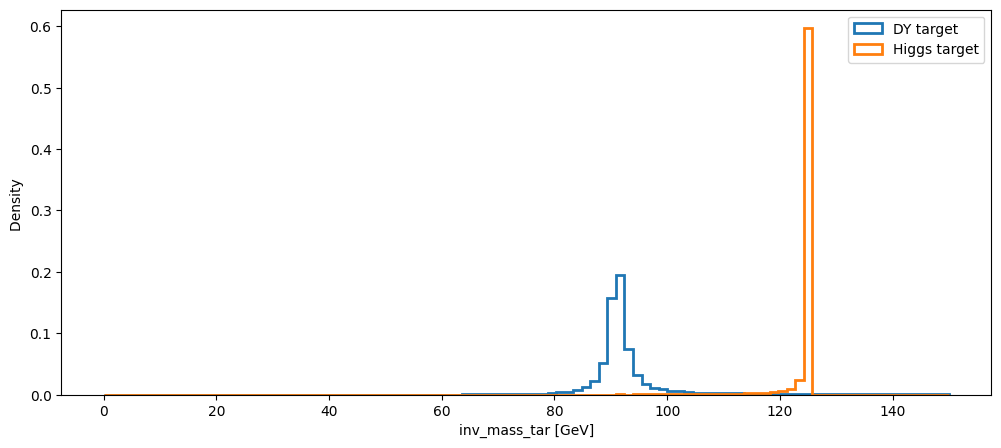

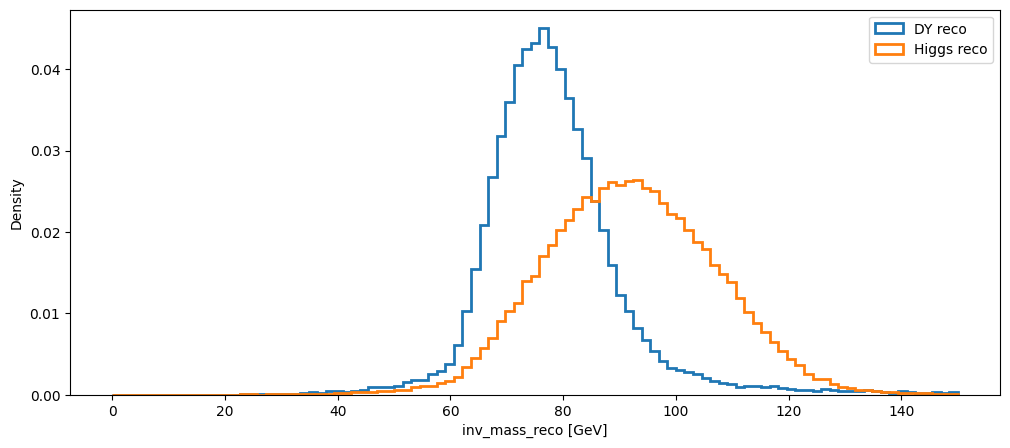

In [53]:
import numpy as np
import matplotlib.pyplot as plt

bins = np.linspace(0, 150, 100)

plt.figure(figsize=(12,5))
plt.hist(df_DY_event["inv_mass_tar"], bins=bins, histtype="step", density=True, label="DY target", linewidth = 2)
plt.hist(df_H_event["inv_mass_tar"], bins=bins, histtype="step", density=True, label="Higgs target", linewidth = 2)
plt.xlabel("inv_mass_tar [GeV]")
plt.ylabel("Density ")
plt.legend()
plt.show()

plt.figure(figsize=(12,5))
plt.hist(df_DY_event["inv_mass_reco"], bins=bins, histtype="step", density=True, label="DY reco",linewidth = 2)
plt.hist(df_H_event["inv_mass_reco"], bins=bins, histtype="step", density=True, label="Higgs reco",linewidth = 2)
plt.xlabel("inv_mass_reco [GeV]")
plt.ylabel("Density")
plt.legend()
plt.show()


# Model

In [54]:
import time
import torch

from torch import nn, Tensor

from flow_matching.path.scheduler import CondOTScheduler
from flow_matching.path import AffineProbPath
from flow_matching.solver import Solver, ODESolver
from flow_matching.utils import ModelWrapper

import matplotlib.pyplot as plt

from matplotlib import cm

import warnings

warnings.filterwarnings("ignore", category=UserWarning, module='torch')

In [55]:
tau1_cols = [
    "tau1_logpt", "tau1_eta", "tau1_phi", "tau1_mass",
    "tau1_dxy", "tau1_dz",
    "tau1_ptCorrPNet", "tau1_rawPNetVSjet", "tau1_rawDeepTau2018v2p5VSjet",
    "tau1_charge",
    "tau1_dM_0", "tau1_dM_1", "tau1_dM_2", "tau1_dM_10", "tau1_dM_11",
    "tau1_leadTkDeltaEta", "tau1_leadTkDeltaPhi", "tau1_leadTkPtOverTauPt", 
    # "tau1_ptreco_over_ptgen",
 #   "gen_tau1_logpt"
]

tau2_cols = [
    "tau2_logpt", "tau2_eta", "tau2_phi", "tau2_mass",
    "tau2_dxy", "tau2_dz",
    "tau2_ptCorrPNet", "tau2_rawPNetVSjet", "tau2_rawDeepTau2018v2p5VSjet",
    "tau2_charge",
    "tau2_dM_0", "tau2_dM_1", "tau2_dM_2", "tau2_dM_10", "tau2_dM_11",
    "tau2_leadTkDeltaEta", "tau2_leadTkDeltaPhi", "tau2_leadTkPtOverTauPt", 
    # "tau2_ptreco_over_ptgen",
  #  "gen_tau2_logpt",
]

jet_cols = [
    "jet1_logpt", "jet1_eta", "jet1_phi", "jet1_mass",
    "jet2_logpt", "jet2_eta", "jet2_phi", "jet2_mass",
    "jet3_logpt", "jet3_eta", "jet3_phi", "jet3_mass",
]

met_cols = [
    "MET_logpt","MET_phi","MET_covXX","MET_covXY",
    "MET_covYY","MET_significance","MET_sumEt","MET_sumPtUnclustered"
]

# gen_cols = ["gen_tau1_logpt", "gen_tau2_logpt"]

# mass_cols = ["inv_mass_reco", "inv_mass_tar"]

class_col = ["class"]

df_DY_event["class"] = 0  
df_H_event["class"] = 1

In [56]:
met_cols_reduced = [
    "MET_logpt",
    "MET_phi",
    "MET_significance",
    "MET_sumEt",
]

In [57]:
train_cols = (
    tau1_cols
    + tau2_cols
    + jet_cols
    + met_cols_reduced
)

In [58]:
# Target: fattore di correzione

eps = 1e-8
for df in [df_DY_event, df_H_event]:
    df["tau1_corr"] = df["tau1_pt_gen"] / np.clip(df["tau1_pt_reco_corrPNet"], eps, None)
    df["tau2_corr"] = df["tau2_pt_gen"] / np.clip(df["tau2_pt_reco_corrPNet"], eps, None)

y_cols = ["tau1_corr", "tau2_corr"]


In [59]:
# Concateno DY e H: 
df_DY_event["class"] = 0  
df_H_event["class"]  = 1 

df_all = (
    pd.concat([df_DY_event, df_H_event], axis=0)
      .sample(frac=1.0, random_state=42)
      .reset_index(drop=True)
)


# Model

# 1. Balanced vs Unbalanced

In [61]:
# ============================================================
# 1 — MODEL (CFM) + LOSS + SAMPLING (NO scaling)
# ============================================================
import copy
import math
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split  


# -----------------------
# Reproducibility
# -----------------------
def set_seed(seed=42):
    import random
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


# -----------------------
# Dataset
# -----------------------
class TabularFMDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return self.X.shape[0]

    def __getitem__(self, i):
        return self.X[i], self.y[i]


# -----------------------
# Time embedding
# -----------------------
class FourierTimeEmbedding(nn.Module):
    def __init__(self, embed_dim=64, max_freq=10.0):
        super().__init__()
        assert embed_dim % 2 == 0
        freqs = torch.linspace(1.0, max_freq, embed_dim // 2)
        self.register_buffer("freqs", freqs)

    def forward(self, t):
        # t: (B,) in [0,1]
        # returns (B, embed_dim)
        angles = 2.0 * math.pi * t[:, None] * self.freqs[None, :]
        return torch.cat([torch.sin(angles), torch.cos(angles)], dim=-1)


# -----------------------
# Conditional velocity field v_theta(t, x_t, context)
# -----------------------
class ConditionalVelocityField(nn.Module):
    def __init__(
        self,
        x_dim: int,          # y-dim (2)
        context_dim: int,    # len(train_cols)
        hidden=(256, 256, 256),
        time_embed_dim=64,
        dropout=0.0,
    ):
        super().__init__()
        self.time_embed = FourierTimeEmbedding(embed_dim=time_embed_dim, max_freq=10.0)

        in_dim = x_dim + context_dim + time_embed_dim
        layers = []
        d = in_dim
        for h in hidden:
            layers += [nn.Linear(d, h), nn.SiLU()]
            if dropout > 0:
                layers += [nn.Dropout(dropout)]
            d = h
        layers += [nn.Linear(d, x_dim)]
        self.net = nn.Sequential(*layers)

    def forward(self, t, x_t, context):
        # t: (B,)
        # x_t: (B, x_dim)
        # context: (B, context_dim)
        t_emb = self.time_embed(t)
        inp = torch.cat([x_t, context, t_emb], dim=-1)
        return self.net(inp)


# -----------------------
# Flow Matching loss (linear path) — NO scaling, NO log
# -----------------------
def fm_loss(model, context, x1, device):
    """
    context: (B, C)
    x1: (B, x_dim)   target y (NO scaling, NO log)
    """
    B, x_dim = x1.shape
    t = torch.rand(B, device=device)          # Uniform(0,1)
    x0 = torch.randn(B, x_dim, device=device) # base N(0,I)

    x_t = (1.0 - t)[:, None] * x0 + t[:, None] * x1
    v_star = x1 - x0

    v_pred = model(t, x_t, context)
    return torch.mean((v_pred - v_star) ** 2)


# -----------------------
# Sampling: integrate ODE from t=0 to t=1 (Euler)
# -----------------------
@torch.no_grad()
def sample_y(model, context, n_steps=50, device="cpu"):
    """
    context: (B, C) torch.float32
    returns x1_hat: (B, x_dim)
    """
    model.eval()
    B = context.shape[0]
    x_dim = model.net[-1].out_features

    x = torch.randn(B, x_dim, device=device)  # x(t=0)
    dt = 1.0 / n_steps

    for k in range(n_steps):
        t = torch.full((B,), k * dt, device=device)
        v = model(t, x, context)
        x = x + dt * v  # Euler

    return x  # approx x(t=1)


# -----------------------
# Prediction helper (NO scaling) — uses sample_y
# -----------------------
@torch.no_grad()
def predict_tau_corr_general(
    df,
    res,                 # dict returned by train_conditional_flow_matching
    train_cols,
    y_cols,
    n_steps=60,
    batch_size=8192,
):
    """
    Predict y (tau corrections) for a dataframe, with NO scaling assumptions.
    Returns a DataFrame with columns: y_cols + '_pred' and tau1_corr_pred/tau2_corr_pred.

    res must contain:
      - res["model"]
      - res["device"]
    """
    model = res["model"]
    device = res.get("device", "cpu")

    X = df[train_cols].to_numpy(dtype=np.float32)
    X_t = torch.tensor(X, dtype=torch.float32, device=device)

    preds = []
    N = X_t.shape[0]

    for start in range(0, N, batch_size):
        end = min(start + batch_size, N)
        ctx = X_t[start:end]
        y_hat = sample_y(model, ctx, n_steps=n_steps, device=device)  # (b, x_dim)
        preds.append(y_hat.detach().cpu().numpy())

    y_pred = np.concatenate(preds, axis=0)  # (N, len(y_cols))

    out = pd.DataFrame(y_pred, columns=[f"{c}_pred" for c in y_cols], index=df.index)

    if len(y_cols) >= 2:
        out.rename(columns={
            f"{y_cols[0]}_pred": "tau1_corr_pred",
            f"{y_cols[1]}_pred": "tau2_corr_pred",
        }, inplace=True)

    return out


In [76]:
# ============================================================
# 2 — UTILITIES + TRAINING (NO scaling) + MASS PLOTS (2x2 TRAIN/TEST)
# ============================================================
import copy
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader


# ------------------------------------------------------------
# Utilities: balance + split + early stopping
# ------------------------------------------------------------
def make_balanced_df(df, class_col="class", seed=42):
    """
    Downsample the majority class to match the minority class.
    Returns a shuffled balanced dataframe.
    """
    df0 = df[df[class_col] == 0]  # DY
    df1 = df[df[class_col] == 1]  # Higgs
    n = min(len(df0), len(df1))
    df0b = df0.sample(n=n, random_state=seed, replace=False)
    df1b = df1.sample(n=n, random_state=seed, replace=False)
    return (
        pd.concat([df0b, df1b], axis=0)
          .sample(frac=1.0, random_state=seed)
          .reset_index(drop=True)
    )


def split_80_10_10(df, class_col="class", seed=42):
    """
    Stratified 80/10/10 split (when class_col is present).
    """
    strat = df[class_col] if (class_col in df.columns) else None
    df_train, df_tmp = train_test_split(
        df, test_size=0.20, random_state=seed, shuffle=True, stratify=strat
    )
    strat_tmp = df_tmp[class_col] if (class_col in df_tmp.columns) else None
    df_val, df_test = train_test_split(
        df_tmp, test_size=0.50, random_state=seed, shuffle=True, stratify=strat_tmp
    )
    return (
        df_train.reset_index(drop=True),
        df_val.reset_index(drop=True),
        df_test.reset_index(drop=True),
    )


def summarize_splits(df_train, df_val, df_test, class_col="class"):
    def frac(df):
        vc = df[class_col].value_counts(normalize=True).to_dict()
        return {k: round(v, 3) for k, v in vc.items()}

    print("Split summary")
    print(f"  Train: {len(df_train):>8}  frac: {frac(df_train)}")
    print(f"  Val  : {len(df_val):>8}  frac: {frac(df_val)}")
    print(f"  Test : {len(df_test):>8}  frac: {frac(df_test)}")


class EarlyStopping:
    def __init__(self, patience=10, min_delta=0.0):
        self.patience = int(patience)
        self.min_delta = float(min_delta)
        self.best = np.inf
        self.count = 0
        self.best_state = None

    def step(self, val_loss, model):
        improved = (self.best - val_loss) > self.min_delta
        if improved:
            self.best = val_loss
            self.count = 0
            self.best_state = copy.deepcopy(model.state_dict())
            return False
        self.count += 1
        return self.count >= self.patience


# ------------------------------------------------------------
# NO-SCALING: prepare arrays directly from df splits
# ------------------------------------------------------------
def prepare_arrays_noscale(df_train, df_val, df_test, train_cols, y_cols):
    """
    No scaling, no log.
    Returns Xtr/Xva/Xte, ytr/yva/yte in float32.
    """
    def get_X(df):
        return df[train_cols].to_numpy(dtype=np.float32)

    def get_y(df):
        return df[y_cols].to_numpy(dtype=np.float32)

    Xtr = get_X(df_train)
    Xva = get_X(df_val)
    Xte = get_X(df_test)

    ytr = get_y(df_train)
    yva = get_y(df_val)
    yte = get_y(df_test)

    scalers = {"mode": "NO_SCALING"}
    return Xtr, Xva, Xte, ytr, yva, yte, scalers


# ------------------------------------------------------------
# Mass helpers: invariant mass from (pt,eta,phi,m)
# ------------------------------------------------------------
def pt_eta_phi_m_to_p4(pt, eta, phi, m):
    """
    Arrays -> (E, px, py, pz)
    """
    pt  = np.asarray(pt)
    eta = np.asarray(eta)
    phi = np.asarray(phi)
    m   = np.asarray(m)

    px = pt * np.cos(phi)
    py = pt * np.sin(phi)
    pz = pt * np.sinh(eta)

    p2 = px**2 + py**2 + pz**2
    E  = np.sqrt(np.maximum(p2 + m**2, 0.0))
    return E, px, py, pz


def inv_mass_two_objects(pt1, eta1, phi1, m1, pt2, eta2, phi2, m2):
    E1, px1, py1, pz1 = pt_eta_phi_m_to_p4(pt1, eta1, phi1, m1)
    E2, px2, py2, pz2 = pt_eta_phi_m_to_p4(pt2, eta2, phi2, m2)

    E  = E1 + E2
    px = px1 + px2
    py = py1 + py2
    pz = pz1 + pz2

    m2_tot = E**2 - (px**2 + py**2 + pz**2)
    return np.sqrt(np.maximum(m2_tot, 0.0))


def add_fm_mass_columns(
    df,
    df_pred,
    pt1_col="tau1_pt_reco_corrPNet",
    pt2_col="tau2_pt_reco_corrPNet",
    eta1_col="tau1_eta", phi1_col="tau1_phi", m1_col="tau1_mass",
    eta2_col="tau2_eta", phi2_col="tau2_phi", m2_col="tau2_mass",
    out_mass_col="inv_mass_FM",
    clip_corr=(0.0, 5.0),
):
    """
    Adds pt-corrected and invariant mass column using FM predictions.
    clip_corr is a safety clamp for pathological predictions.
    """
    df = df.copy()
    df["tau1_corr_pred"] = df_pred["tau1_corr_pred"].values
    df["tau2_corr_pred"] = df_pred["tau2_corr_pred"].values

    if clip_corr is not None:
        lo, hi = clip_corr
        df["tau1_corr_pred"] = df["tau1_corr_pred"].clip(lo, hi)
        df["tau2_corr_pred"] = df["tau2_corr_pred"].clip(lo, hi)

    df["tau1_pt_FM"] = df[pt1_col].values * df["tau1_corr_pred"].values
    df["tau2_pt_FM"] = df[pt2_col].values * df["tau2_corr_pred"].values

    df[out_mass_col] = inv_mass_two_objects(
        df["tau1_pt_FM"].values, df[eta1_col].values, df[phi1_col].values, df[m1_col].values,
        df["tau2_pt_FM"].values, df[eta2_col].values, df[phi2_col].values, df[m2_col].values,
    )
    return df


# ------------------------------------------------------------
# Training loop (balanced/unbalanced + split + NO scaling)
# + mass plots in a single 2x2 grid (TRAIN/TEST x DY/Higgs)
# ------------------------------------------------------------
def train_conditional_flow_matching(
    df_all,
    train_cols,
    y_cols,
    balanced: bool,
    class_col="class",
    seed=42,
    batch_size=2048,
    hidden=(256, 256, 256),
    dropout=0.0,
    lr=2e-4,
    weight_decay=0.0,
    max_epochs=200,
    patience=15,
    min_delta=0.0,
    device=None,
    log_test_each_epoch=False,
    print_every=10,
    make_mass_plots=False,
    mass_reco_col="inv_mass_reco",
    mass_tar_col="inv_mass_tar",
    n_steps=60,
    xlim=(0, 300),
    bins=80,
    clip_corr=(0.0, 5.0),
    fig_title="reco vs target vs FM",
):
    set_seed(seed)
    device = device or ("cuda" if torch.cuda.is_available() else "cpu")

    df_use = df_all.sample(frac=1.0, random_state=seed).reset_index(drop=True)

    df_train, df_val, df_test = split_80_10_10(df_use, class_col=class_col, seed=seed)

    if balanced:
        df_train = make_balanced_df(df_train, class_col=class_col, seed=seed)

    summarize_splits(df_train, df_val, df_test, class_col=class_col)

    # --- NO SCALING ---
    Xtr, Xva, Xte, ytr, yva, yte, scalers = prepare_arrays_noscale(
        df_train, df_val, df_test, train_cols, y_cols
    )

    train_loader = DataLoader(TabularFMDataset(Xtr, ytr), batch_size=batch_size, shuffle=True, drop_last=True)
    val_loader   = DataLoader(TabularFMDataset(Xva, yva), batch_size=batch_size, shuffle=False)
    test_loader  = DataLoader(TabularFMDataset(Xte, yte), batch_size=batch_size, shuffle=False)

    model = ConditionalVelocityField(
        x_dim=len(y_cols),
        context_dim=len(train_cols),
        hidden=hidden,
        time_embed_dim=64,
        dropout=dropout,
    ).to(device)

    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    stopper = EarlyStopping(patience=patience, min_delta=min_delta)

    history = {"train_loss": [], "val_loss": []}
    if log_test_each_epoch:
        history["test_loss"] = []

    best_epoch = None
    best_val = np.inf

    for epoch in range(1, max_epochs + 1):
        model.train()
        tr_losses = []
        for Xb, yb in train_loader:
            Xb = Xb.to(device)
            yb = yb.to(device)

            loss = fm_loss(model, context=Xb, x1=yb, device=device)

            opt.zero_grad(set_to_none=True)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            opt.step()

            tr_losses.append(loss.item())

        train_loss = float(np.mean(tr_losses)) if tr_losses else np.nan

        model.eval()
        va_losses = []
        with torch.no_grad():
            for Xb, yb in val_loader:
                Xb = Xb.to(device)
                yb = yb.to(device)
                loss = fm_loss(model, context=Xb, x1=yb, device=device)
                va_losses.append(loss.item())

        val_loss = float(np.mean(va_losses)) if va_losses else np.nan

        test_loss_epoch = None
        if log_test_each_epoch:
            te_losses = []
            with torch.no_grad():
                for Xb, yb in test_loader:
                    Xb = Xb.to(device)
                    yb = yb.to(device)
                    loss = fm_loss(model, context=Xb, x1=yb, device=device)
                    te_losses.append(loss.item())
            test_loss_epoch = float(np.mean(te_losses)) if te_losses else np.nan
            history["test_loss"].append(test_loss_epoch)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)

        if (epoch == 1) or (print_every and (epoch % print_every == 0)):
            msg = f"[Epoch {epoch:4d}] train={train_loss:.4e} | val={val_loss:.4e}"
            if log_test_each_epoch:
                msg += f" | test={test_loss_epoch:.4e}"
            print(msg)

        if val_loss < best_val:
            best_val = val_loss
            best_epoch = epoch

        if stopper.step(val_loss, model):
            print(f"Early stopping at epoch {epoch} (best epoch={best_epoch}, best val={best_val:.4e})")
            break

    if stopper.best_state is not None:
        model.load_state_dict(stopper.best_state)

    # final test loss
    model.eval()
    te_losses = []
    with torch.no_grad():
        for Xb, yb in test_loader:
            Xb = Xb.to(device)
            yb = yb.to(device)
            loss = fm_loss(model, context=Xb, x1=yb, device=device)
            te_losses.append(loss.item())
    test_loss = float(np.mean(te_losses)) if te_losses else np.nan

    out = {
        "model": model,
        "history": history,
        "best_epoch": best_epoch,
        "test_loss": test_loss,
        "scalers": scalers,
        "device": device,
        "df_splits": (df_train, df_val, df_test),
        "train_cols": train_cols,
        "y_cols": y_cols,
    }

    # --------------------------------------------------------
    # Mass plots: 2x2 grid (TRAIN/TEST x DY/Higgs)
    # --------------------------------------------------------
    if make_mass_plots:
        # TRAIN
        df_pred_tr = predict_tau_corr_general(df_train, out, train_cols, y_cols, n_steps=n_steps)
        df_plot_tr = add_fm_mass_columns(df_train, df_pred_tr, out_mass_col="inv_mass_FM", clip_corr=clip_corr)

        # TEST
        df_pred_te = predict_tau_corr_general(df_test, out, train_cols, y_cols, n_steps=n_steps)
        df_plot_te = add_fm_mass_columns(df_test, df_pred_te, out_mass_col="inv_mass_FM", clip_corr=clip_corr)

        # split by class
        tr_dy = df_plot_tr[df_plot_tr[class_col] == 0]
        tr_h  = df_plot_tr[df_plot_tr[class_col] == 1]
        te_dy = df_plot_te[df_plot_te[class_col] == 0]
        te_h  = df_plot_te[df_plot_te[class_col] == 1]

        panels = [
            ("TRAIN | DY (class=0)", tr_dy),
            ("TRAIN | Higgs (class=1)", tr_h),
            ("TEST  | DY (class=0)", te_dy),
            ("TEST  | Higgs (class=1)", te_h),
        ]

        fig, axes = plt.subplots(2, 2, figsize=(12, 8))
        axes = axes.ravel()

        for ax, (ttl, dfi) in zip(axes, panels):
       #     ax.hist(dfi[mass_reco_col], bins=bins, density=True, histtype="step", label="reco", lw=2)
            ax.hist(dfi[mass_tar_col],  bins=bins, density=True, histtype="step", label="target", lw=2)
            ax.hist(dfi["inv_mass_FM"], bins=bins, density=True, histtype="step", label="FM", lw=2)
            ax.set_title(ttl)
            ax.set_xlabel("m(ττ) [GeV]")
            ax.set_ylabel("Density")
            ax.grid(alpha=0.25)
            ax.set_xlim(*xlim)

        handles, labels = axes[0].get_legend_handles_labels()
        fig.legend(handles, labels, loc="upper right", bbox_to_anchor=(0.98, 0.98))
        fig.suptitle(fig_title, fontsize=14)
        fig.tight_layout(rect=[0, 0, 1, 0.95])
        plt.show()

        out["df_plot_train"] = df_plot_tr
        out["df_plot_test"] = df_plot_te

    return out


In [68]:
# ============================================================
# Plot training / validation loss vs epochs
# ============================================================
import matplotlib.pyplot as plt

def plot_loss_curves(res, title="Loss vs epochs"):
    train_loss = res["history"]["train_loss"]
    val_loss   = res["history"]["val_loss"]
    epochs = np.arange(1, len(train_loss) + 1)

    plt.figure(figsize=(6.5, 4.5))
    plt.plot(epochs, train_loss, label="Train loss")
    plt.plot(epochs, val_loss,   label="Validation loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(title)
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


Split summary
  Train:   143567  frac: {1: 0.713, 0: 0.287}
  Val  :    17946  frac: {1: 0.713, 0: 0.287}
  Test :    17946  frac: {1: 0.713, 0: 0.287}
[Epoch    1] train=2.9445e+00 | val=1.2413e+00
[Epoch   10] train=1.1143e+00 | val=1.2524e+00
[Epoch   20] train=9.8168e-01 | val=8.2346e-01
[Epoch   30] train=8.1450e-01 | val=7.2017e-01
[Epoch   40] train=7.8395e-01 | val=6.7220e-01
[Epoch   50] train=6.8933e-01 | val=6.2450e-01
[Epoch   60] train=8.1590e-01 | val=6.9076e-01
[Epoch   70] train=6.3181e-01 | val=5.6746e-01
[Epoch   80] train=1.3528e+00 | val=5.8689e-01
Early stopping at epoch 81 (best epoch=66, best val=5.1897e-01)


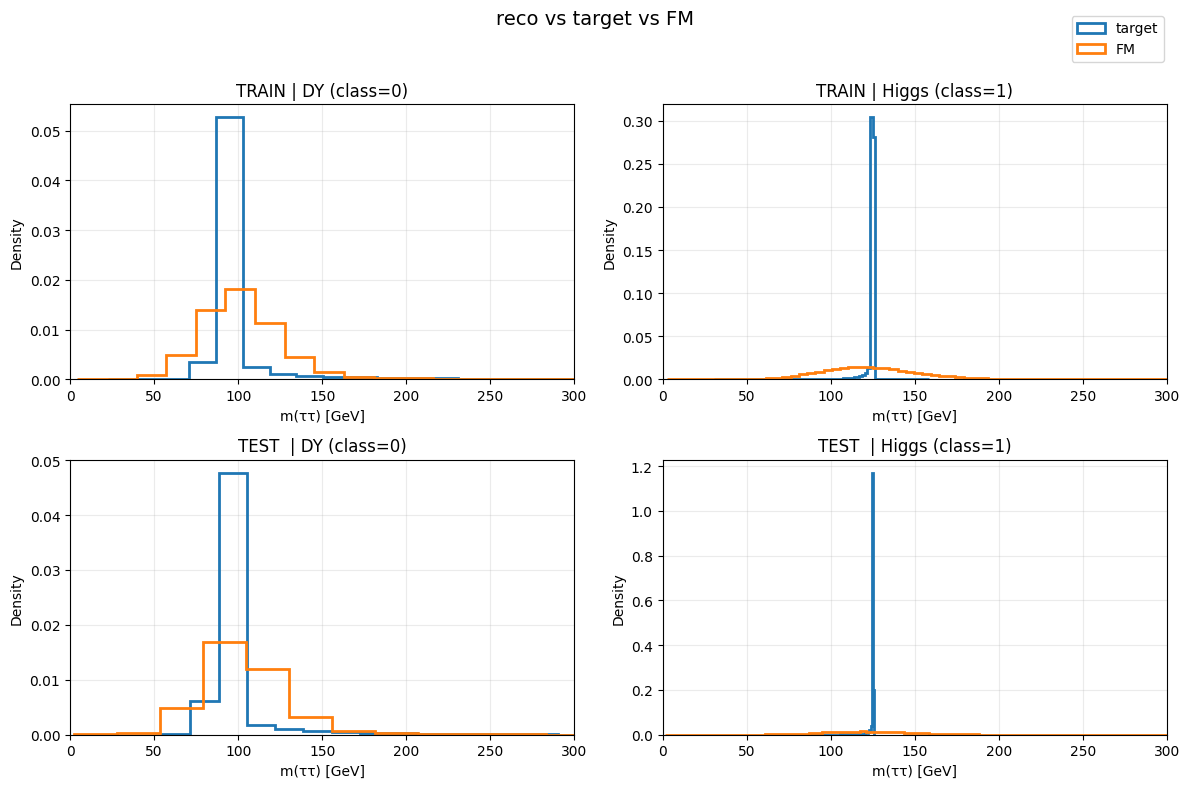

Split summary
  Train:    82280  frac: {1: 0.5, 0: 0.5}
  Val  :    17946  frac: {1: 0.713, 0: 0.287}
  Test :    17946  frac: {1: 0.713, 0: 0.287}
[Epoch    1] train=4.0837e+00 | val=1.4523e+00
[Epoch   10] train=1.1844e+00 | val=1.2740e+00
[Epoch   20] train=1.0380e+00 | val=1.2246e+00
[Epoch   30] train=9.9371e-01 | val=1.0140e+00
[Epoch   40] train=8.2258e-01 | val=8.7542e-01
[Epoch   50] train=9.1908e-01 | val=1.2554e+00
[Epoch   60] train=9.2260e-01 | val=1.1903e+00
Early stopping at epoch 68 (best epoch=53, best val=5.9877e-01)


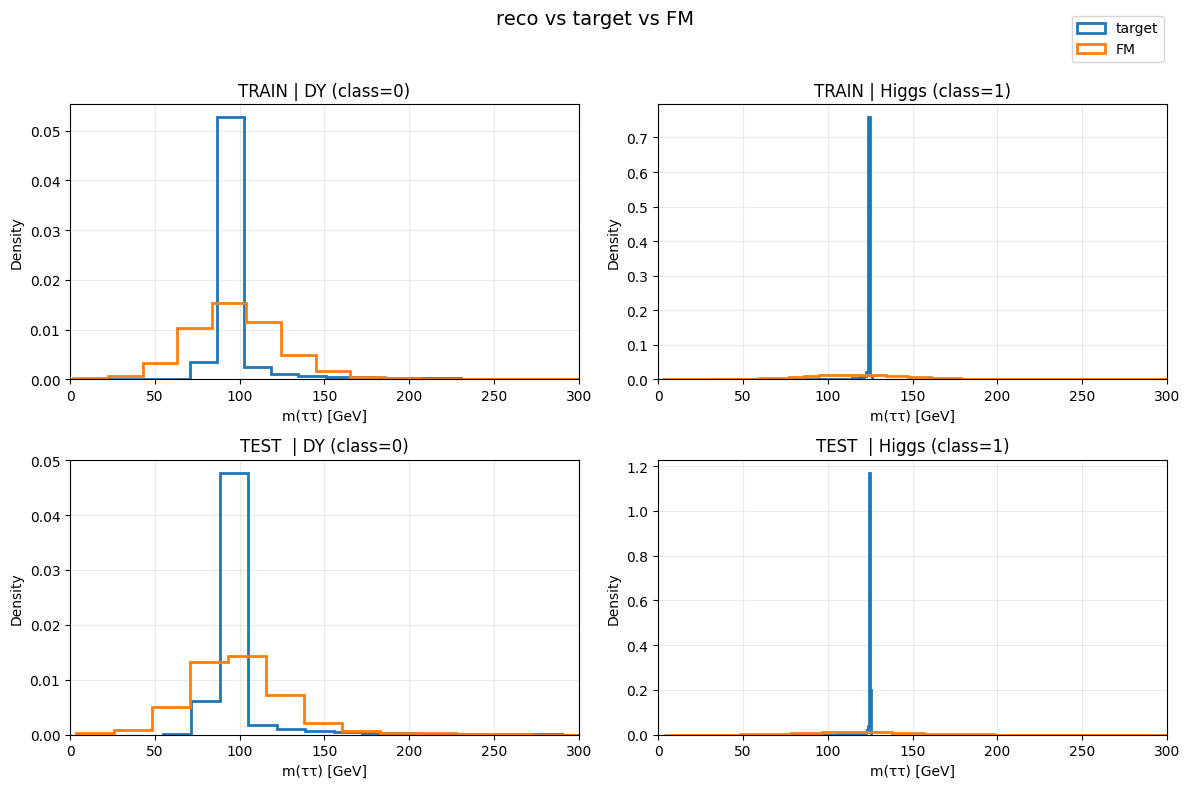

In [77]:
res_unbalanced = train_conditional_flow_matching(
    df_all=df_all,
    train_cols=train_cols,
    y_cols=y_cols,
    balanced=False,
    make_mass_plots=True,
)

res_balanced = train_conditional_flow_matching(
    df_all=df_all,
    train_cols=train_cols,
    y_cols=y_cols,
    balanced=True,
    make_mass_plots=True,
)


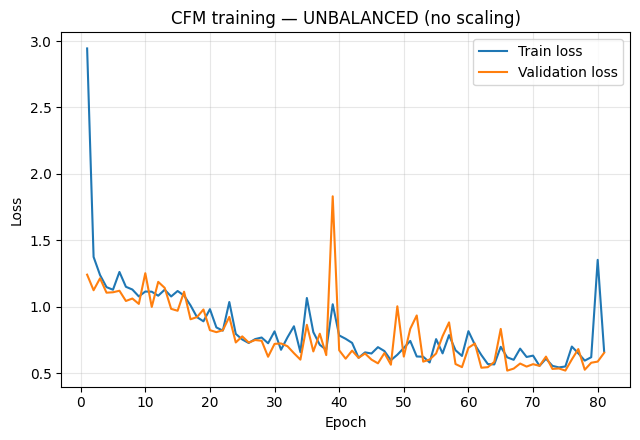

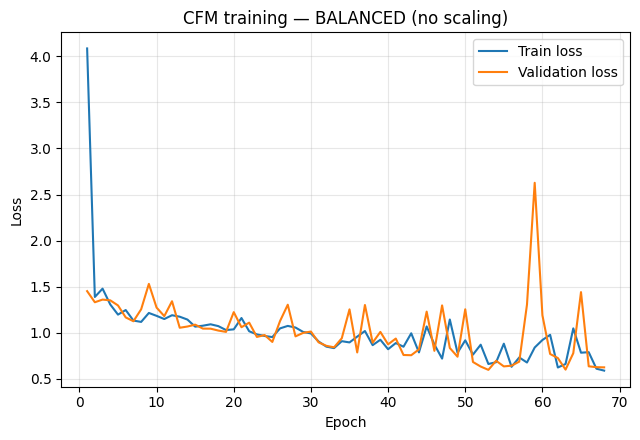

In [78]:
plot_loss_curves(
    res_unbalanced,
    title="CFM training — UNBALANCED (no scaling)"
)

plot_loss_curves(
    res_balanced,
    title="CFM training — BALANCED (no scaling)"
)
